In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import geopandas as gpd

plt.style.use('../style.mplstyle')

In [2]:
d1 = pl.read_csv('./ansix_cmp.csv', infer_schema_length = 1_000_000)
d2 = pl.read_csv('./setrab_cmp.csv', infer_schema_length = 1_000_000)

In [3]:
def kpa_to_psi(kpa: float):
    return kpa*0.1456038

def c_to_f(c: float):
    return c*1.8+32

In [4]:
d1 = d1.with_columns(
    ((pl.col('Engine oil temperature (.C) *canbus') * 1.8) + 32).alias('engine_oil_temp_f'),
    (pl.col('Engine oil pressure (kPa) *canbus') * 0.1456038).alias('engine_oil_pressure_psi')
)


d2 = d2.with_columns(
    ((pl.col('Engine oil temperature (.C) *canbus') * 1.8) + 32).alias('engine_oil_temp_f'),
    (pl.col('Engine oil pressure (kPa) *canbus') * 0.1456038).alias('engine_oil_pressure_psi')
)

In [5]:
d1.group_by('Lap #').agg(
    pl.col('Elapsed time (s)').max() - pl.col('Elapsed time (s)').min()
).sort(by = 'Elapsed time (s)')

Lap #,Elapsed time (s)
i64,f64
3,113.238
4,113.44
7,113.478
6,114.115
5,115.274
2,117.074
1,117.724
8,156.895
null,458.956


In [6]:
d2.group_by('Lap #').agg(
    pl.col('Elapsed time (s)').max() - pl.col('Elapsed time (s)').min()
).sort(by = 'Elapsed time (s)')

Lap #,Elapsed time (s)
i64,f64
5,109.166
7,110.296
4,110.354
3,110.585
6,110.852
2,112.515
1,127.033
8,201.65
null,244.542


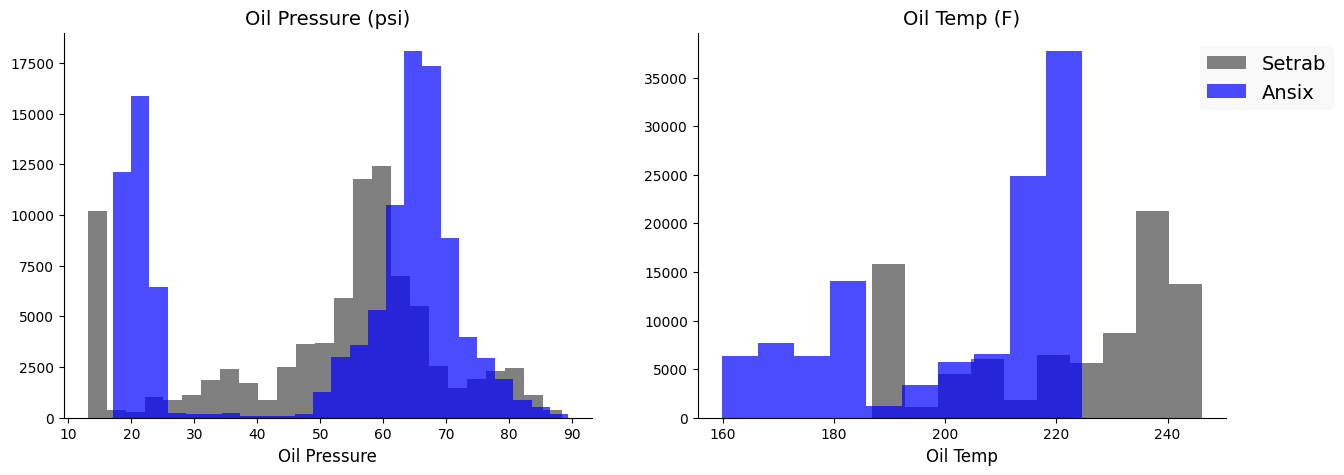

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))
axs = ax.flatten()

a = axs[0]
a.hist(d2['engine_oil_pressure_psi'], bins = 25, alpha = 1., label = 'Setrab', color = 'grey')
a.hist(d1['engine_oil_pressure_psi'], bins = 25, alpha = 0.7, label = 'Ansix', color = 'blue')
a.set_title('Oil Pressure (psi)', fontsize=14)
a.set_xlabel('Oil Pressure')


a = axs[1]
a.hist(d2['engine_oil_temp_f'], bins = 10, label = 'Setrab', alpha = 1., color = 'grey')
a.hist(d1['engine_oil_temp_f'], bins = 10, label = 'Ansix', alpha = 0.7, color = 'blue')
a.set_title('Oil Temp (F)', fontsize=14)
a.set_xlabel('Oil Temp')

a.legend(loc = (0.95,0.8))

#fig.savefig('bw13cw_greddy_comp.png', bbox_inches='tight', facecolor='w', dpi=200)
fig.savefig('./histogram_oil_pressure_temp.png', bbox_inches = 'tight', facecolor = 'w',
           dpi = 200)
pass

In [8]:
ansix_fasteset_lap = 4
setrab_fastest_lap = 5

#
d1_lap = d1.filter(pl.col('Lap #') == ansix_fasteset_lap)
d2_lap = d2.filter(pl.col('Lap #') == setrab_fastest_lap)

#
d1_lap = d1_lap.with_columns(
    (pl.col('Elapsed time (s)') - pl.col('Elapsed time (s)').min()).alias('time')
)

d2_lap = d2_lap.with_columns(
    (pl.col('Elapsed time (s)') - pl.col('Elapsed time (s)').min()).alias('time')
)

# use Setrab as baseline for oil pressure
ref = d2_lap['engine_oil_pressure_psi'].mean()

d1_lap = d1_lap.with_columns(
    (pl.col('engine_oil_pressure_psi') / ref * 100).alias('oil_pressure_percent')
)

d2_lap = d2_lap.with_columns(
    (pl.col('engine_oil_pressure_psi') / ref * 100).alias('oil_pressure_percent')
)

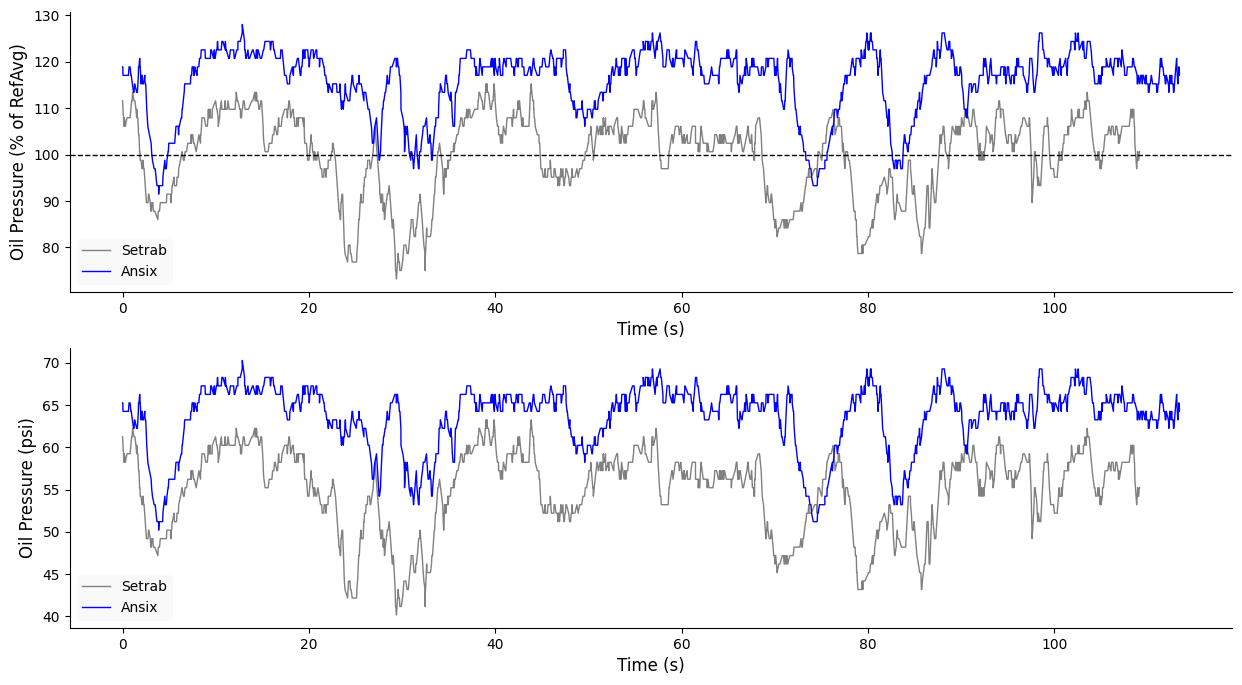

In [26]:
fig, ax = plt.subplots(2,1, figsize=(15,8))
axs = ax.flatten()

a = axs[0]
sns.lineplot(ax = a, x = 'time', y = 'oil_pressure_percent', data = d2_lap, label = 'Setrab', color = 'grey', lw = 1)
sns.lineplot(ax = a, x = 'time', y = 'oil_pressure_percent', data = d1_lap, label = 'Ansix', color = 'blue', lw = 1)
a.axhline(y = 100., ls = 'dashed', color = 'k', lw = 1)
a.set_xlabel('Time (s)')
a.set_ylabel('Oil Pressure (% of RefAvg)')
a.legend(fontsize=10)

a = axs[1]
sns.lineplot(ax = a, x = 'time', y = 'engine_oil_pressure_psi', data = d2_lap, label = 'Setrab', color = 'grey', lw = 1)
sns.lineplot(ax = a, x = 'time', y = 'engine_oil_pressure_psi', data = d1_lap, label = 'Ansix', color = 'blue', lw = 1)
a.set_xlabel('Time (s)')
a.set_ylabel('Oil Pressure (psi)')
a.legend(fontsize=10)

fig.savefig('./fastest_lap_line_oil_pressure.png', bbox_inches = 'tight', facecolor = 'w',
           dpi = 200)
pass

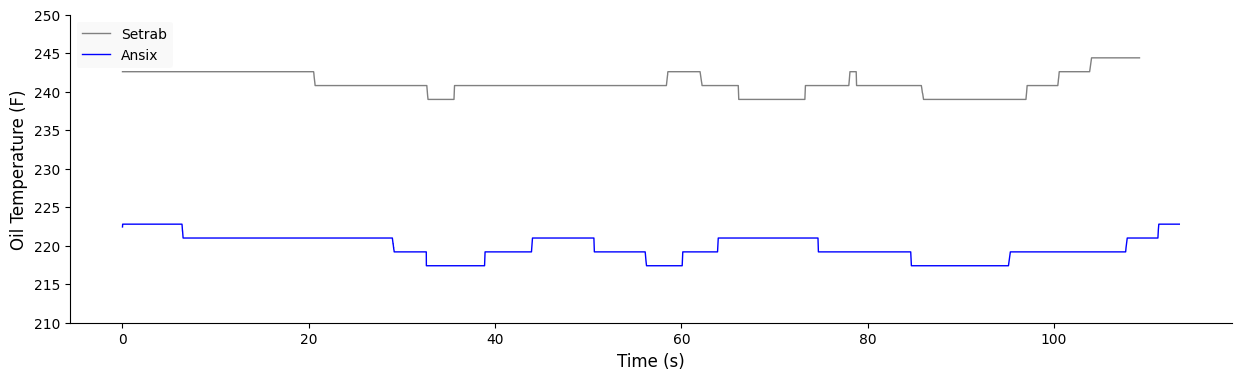

In [27]:
fig, ax = plt.subplots(figsize=(15,4))

sns.lineplot(ax = ax, x = 'time', y = 'engine_oil_temp_f', data = d2_lap, label = 'Setrab', color = 'grey', lw = 1)
sns.lineplot(ax = ax, x = 'time', y = 'engine_oil_temp_f', data = d1_lap, label = 'Ansix', color = 'blue', lw = 1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Oil Temperature (F)')
ax.legend(fontsize=10)
ax.set_ylim([210,250])
fig.savefig('./vincent-yang/fastest_lap_line_oil_temp.png', bbox_inches = 'tight', facecolor = 'w',
           dpi = 200)
pass

In [11]:
d1_lap

Time (s),Session fragment #,Lap #,Trap name,X-position (m),Y-position (m),Distance (m),Speed (m/s),Altitude (m),Bearing (deg),Device update rate (Hz),Elapsed time (s),Latitude (deg),Longitude (deg),Device battery level (%),Satellites (sats),Fix type,Accuracy (m),Speed (m/s) *calc,Lateral acceleration (G) *calc,Longitudinal acceleration (G) *calc,Device update rate (Hz) *calc,Lean angle (deg) *calc,Combined acceleration (G) *calc,Speed (m/s) *canbus,Lateral acceleration (G) *canbus,Steering angle (deg) *canbus,Brake position (%) *canbus,Engine oil pressure (kPa) *canbus,RPM (rpm) *canbus,Coolant temperature (.C) *canbus,Engine oil temperature (.C) *canbus,Accelerator position (%) *canbus,X acceleration (G) *acc,Y acceleration (G) *acc,Z acceleration (G) *acc,Device update rate (Hz) *acc,X rate of rotation (deg/s) *gyro,Y rate of rotation (deg/s) *gyro,Z rate of rotation (deg/s) *gyro,Device update rate (Hz) *gyro,engine_oil_temp_f,engine_oil_pressure_psi,time,oil_pressure_percent
f64,i64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.7711e9,0,4,"""Start/Finish""",152.279,-242.991,11297.174,45.611,143.84,134.863,24.8,807.0,34.486683,-80.595754,88.0,16,3,0.248,45.611,0.035,-0.052,20,-1.988,0.063,43.875,0.071,-0.903,41.8,448.159,6710,93.0,105.8,0.0,-0.293,0.062,0.943,24.8,-0.39,1.27,-0.537,24.8,222.44,65.253653,0.0,118.902813
1.7711e9,0,4,null,152.798,-243.516,11297.913,45.621,143.828,134.863,24.8,807.017,34.486678,-80.595748,88.0,16,3,0.248,45.613,0.034,-0.072,20,-1.916,0.08,43.708,0.069,-0.943,45.7,448.159,6686,93.0,106.0,0.0,-0.427,0.062,0.973,24.8,-0.568,0.963,-0.639,24.8,222.8,65.253653,0.017,118.902813
1.7711e9,0,4,null,152.861,-243.579,11298.002,45.622,143.826,134.863,24.8,807.019,34.486678,-80.595747,88.0,16,3,0.248,45.613,0.033,-0.074,20,-1.907,0.082,43.688,0.069,-0.948,46.2,447.348,6683,93.0,106.0,0.0,-0.443,0.062,0.977,24.8,-0.59,0.926,-0.651,24.8,222.8,65.135569,0.019,118.687643
1.7711e9,0,4,null,153.33,-244.053,11298.669,45.63,143.815,134.863,24.8,807.034,34.486674,-80.595742,88.0,16,3,0.248,45.615,0.032,-0.092,20,-1.842,0.098,43.538,0.067,-0.984,49.7,441.265,6650,93.0,106.0,0.0,-0.564,0.061,1.004,24.8,-0.751,0.648,-0.742,24.8,222.8,64.249861,0.034,117.073739
1.7711e9,0,4,null,153.549,-244.275,11298.981,45.634,143.81,134.842,24.7,807.041,34.486672,-80.59574,88.0,16,3,0.248,45.615,0.032,-0.1,20,-1.812,0.106,43.467,0.066,-1.001,51.4,441.265,6635,93.0,106.0,0.0,-0.62,0.061,1.017,24.7,-0.826,0.518,-0.785,24.7,222.8,64.249861,0.041,117.073739
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1.7711e9,0,4,null,150.616,-241.662,14929.533,44.96,144.074,134.873,25.0,920.4,34.486695,-80.595772,88.0,16,3,0.244,44.96,-0.049,-0.076,20,2.778,0.09,43.23,0.048,-4.124,44.2,444.823,6562,93.0,106.0,0.0,-0.217,-0.034,0.984,25.0,1.264,0.378,-0.485,25.0,222.8,64.767919,113.4,118.017725
1.7711e9,0,4,null,151.631,-242.685,14930.974,44.948,144.049,134.873,25.0,920.432,34.486686,-80.595761,88.0,16,3,0.244,44.943,-0.044,-0.11,20,2.498,0.119,43.079,0.059,-4.449,47.5,441.265,6541,93.0,106.0,0.0,-0.217,-0.034,0.984,25.0,1.264,0.378,-0.485,25.0,222.8,64.249861,113.432,117.073739
1.7711e9,0,4,null,151.694,-242.749,14931.064,44.947,144.048,134.873,25.0,920.434,34.486685,-80.59576,88.0,16,3,0.244,44.941,-0.043,-0.112,20,2.48,0.121,43.07,0.06,-4.469,47.7,441.864,6540,93.0,106.0,0.0,-0.217,-0.034,0.984,25.0,1.264,0.378,-0.485,25.0,222.8,64.337077,113.434,117.232662


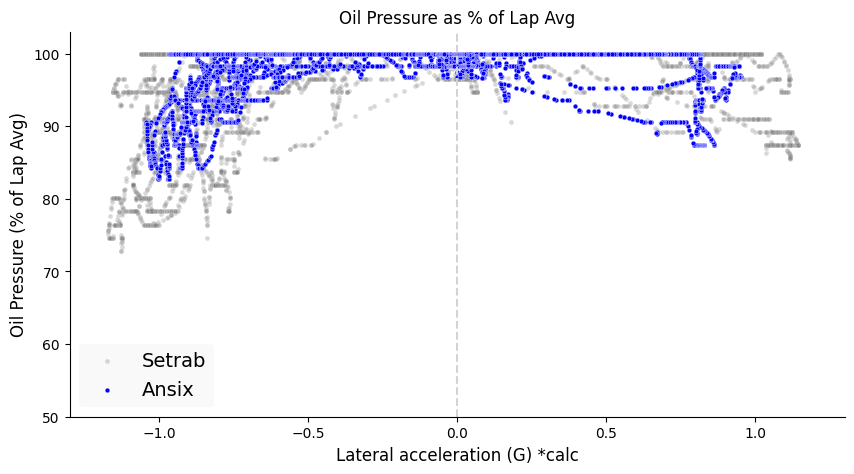

In [31]:
rpm_thresh = 4000

fig, ax = plt.subplots(figsize=(10,5))

d1_copy = d1_lap.filter(pl.col('RPM (rpm) *canbus') > rpm_thresh)
d2_copy = d2_lap.filter(pl.col('RPM (rpm) *canbus') > rpm_thresh)

d1_avg_pressure = d1_copy['engine_oil_pressure_psi'].mean()
d2_avg_pressure = d2_copy['engine_oil_pressure_psi'].mean()

d1_copy = d1_copy.with_columns(
    (pl.col('engine_oil_pressure_psi') / d1_avg_pressure * 100).alias('% drop').clip(upper_bound = 100)
)

d2_copy = d2_copy.with_columns(
    (pl.col('engine_oil_pressure_psi') / d2_avg_pressure * 100).alias('% drop').clip(upper_bound = 100)
)

# setrab
sns.scatterplot(ax = ax,
                x = "Lateral acceleration (G) *calc",
                y = '% drop', data = d2_copy, color = 'grey', s=12, legend="auto", alpha = 0.3,
               label = 'Setrab')

# ansix
sns.scatterplot(ax = ax,
                x = "Lateral acceleration (G) *calc",
                y = '% drop', data = d1_copy, color = 'blue', s=12, legend="auto",
               label = 'Ansix')


ax.axvline(x=0, color='lightgray', linestyle='--')
#ax.set_ylim([50,100])
ax.set_xlim([-1.3,1.3])
ax.set_title('Oil Pressure as % of Lap Avg')
ax.set_ylabel('Oil Pressure (% of Lap Avg)')
# ax.set_xlabel('Lateral Acceleration (G)')
ax.set_ylim([50, 103])  # Set the y-axis limit to 0-100
# ax.get_legend().set_title(None)
fig.savefig('./scatter_lat_acc_oil_pressure.png', bbox_inches = 'tight', facecolor = 'w',
           dpi = 200)
pass

In [13]:
d1_lap_pd = d1_lap.to_pandas()
d2_lap_pd = d2_lap.to_pandas()

d1_lap_gpd = gpd.GeoDataFrame(data = d1_lap_pd,
                              geometry = gpd.points_from_xy(d1_lap_pd['Longitude (deg)'], d1_lap_pd['Latitude (deg)']))
d2_lap_gpd = gpd.GeoDataFrame(data = d2_lap_pd,
                              geometry = gpd.points_from_xy(d2_lap_pd['Longitude (deg)'], d2_lap_pd['Latitude (deg)']))

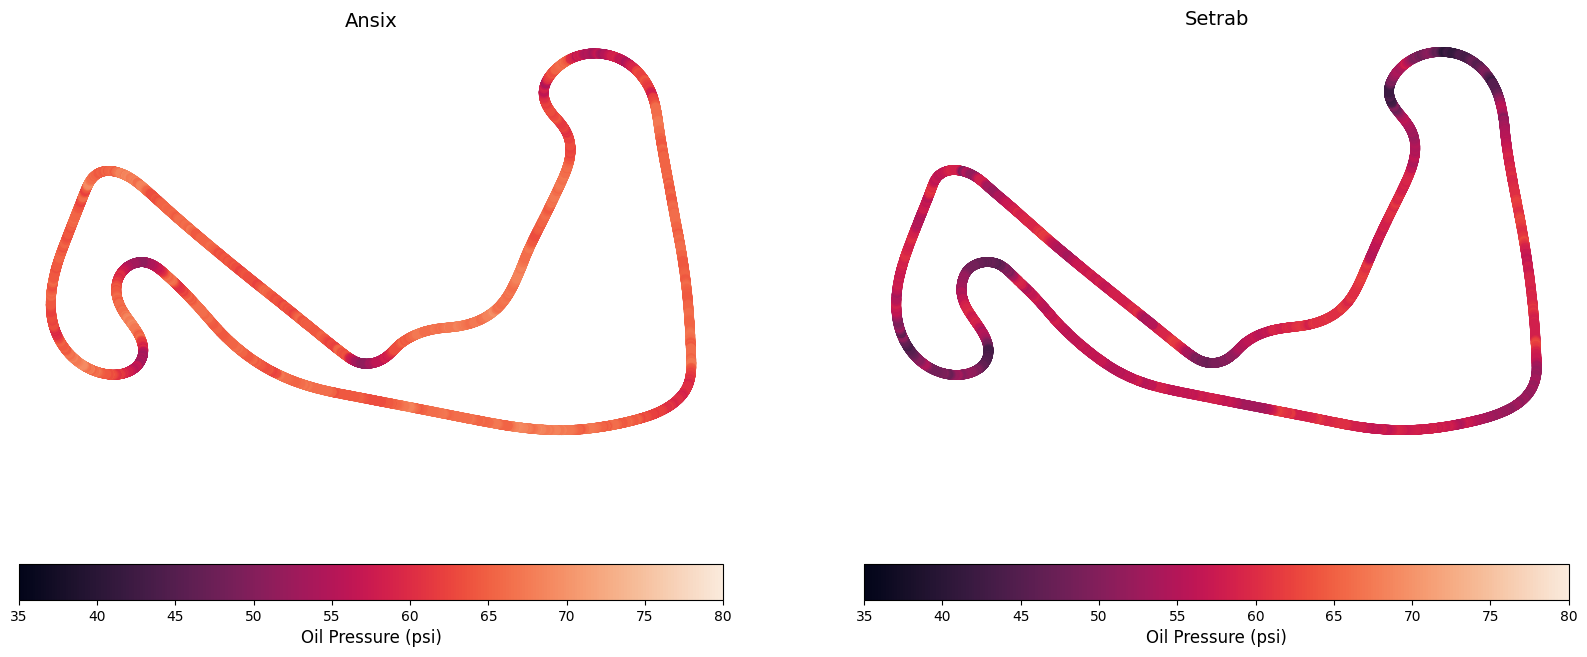

In [29]:
col = 'engine_oil_pressure_psi'

fig, ax = plt.subplots(1, 2, figsize=(20,10))
axs = ax.flatten()

a = axs[0]
d1_lap_gpd.plot(ax = a, column = col, legend=True, vmin=35, vmax=80, cmap = 'rocket',
               legend_kwds={'label': "Oil Pressure (psi)",
                            'orientation': "horizontal"})
a.axis('off')
a.set_title('Ansix', fontsize=14)

a = axs[1]
d2_lap_gpd.plot(ax = a, column = col, legend=True, vmin=35, vmax=80, cmap = 'rocket',
               legend_kwds={'label': "Oil Pressure (psi)",
                            'orientation': "horizontal"})
a.axis('off')
a.set_title('Setrab', fontsize=14)
fig.savefig('./gps_oil_pressure.png', bbox_inches = 'tight', facecolor = 'w',
           dpi = 200)
pass

In [ ]:
d1_lap['engine_oil_pressure_psi'].min()

In [ ]:
d2_lap['engine_oil_pressure_psi'].min()

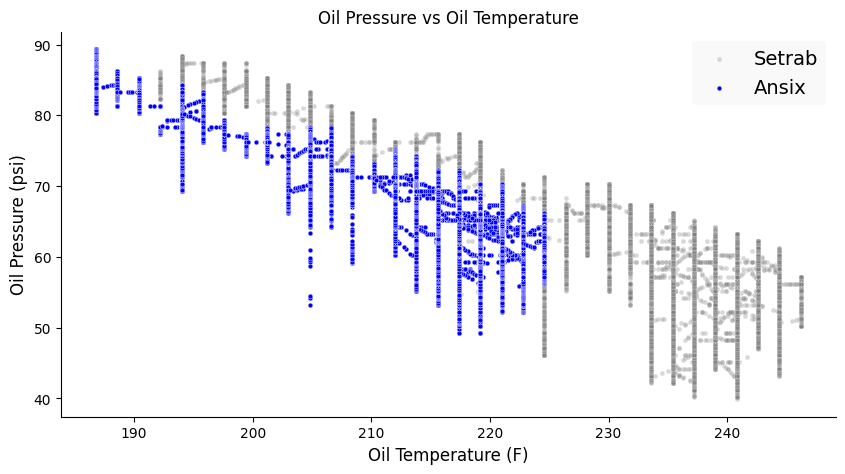

In [38]:
fig, ax = plt.subplots(figsize=(10,5))

d1_filt = d1.filter(pl.col('RPM (rpm) *canbus') > 4000)
d2_filt = d2.filter(pl.col('RPM (rpm) *canbus') > 4000)

# setrab
sns.scatterplot(ax = ax,
                x = "engine_oil_temp_f",
                y = 'engine_oil_pressure_psi',
                data = d2_filt, color = 'grey', s=12, legend="auto", alpha = 0.3,
               label = 'Setrab')

# ansix
sns.scatterplot(ax = ax,
                x = "engine_oil_temp_f",
                y = 'engine_oil_pressure_psi',
                data = d1_filt, color = 'blue', s=12, legend="auto",
               label = 'Ansix')


#ax.axvline(x=0, color='lightgray', linestyle='--')
#ax.set_ylim([50,100])
#ax.set_xlim([-1.3,1.3])
ax.set_title('Oil Pressure vs Oil Temperature')
ax.set_ylabel('Oil Pressure (psi)')
ax.set_xlabel('Oil Temperature (F)')
#ax.set_ylim([50, 103])  # Set the y-axis limit to 0-100
# ax.get_legend().set_title(None)
fig.savefig('./scatter_oil_pressure_temp.png', bbox_inches = 'tight', facecolor = 'w',
           dpi = 200)
pass